In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(r"C:\Users\msamp\Downloads\schl\StudentPerformanceFactors.csv")

In [3]:
data.shape

(6607, 20)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [5]:
data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [6]:
print(data)

      Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0                23          84                  Low                High   
1                19          64                  Low              Medium   
2                24          98               Medium              Medium   
3                29          89                  Low              Medium   
4                19          92               Medium              Medium   
...             ...         ...                  ...                 ...   
6602             25          69                 High              Medium   
6603             23          76                 High              Medium   
6604             20          90               Medium                 Low   
6605             10          86                 High                High   
6606             15          67               Medium                 Low   

     Extracurricular_Activities  Sleep_Hours  Previous_Scores  \
0                     

## Standardizing Column Names

In [7]:
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')
print("Updated column names:")
print(data.columns.tolist())

Updated column names:
['hours_studied', 'attendance', 'parental_involvement', 'access_to_resources', 'extracurricular_activities', 'sleep_hours', 'previous_scores', 'motivation_level', 'internet_access', 'tutoring_sessions', 'family_income', 'teacher_quality', 'school_type', 'peer_influence', 'physical_activity', 'learning_disabilities', 'parental_education_level', 'distance_from_home', 'gender', 'exam_score']


In [8]:
data.isnull().sum()

hours_studied                  0
attendance                     0
parental_involvement           0
access_to_resources            0
extracurricular_activities     0
sleep_hours                    0
previous_scores                0
motivation_level               0
internet_access                0
tutoring_sessions              0
family_income                  0
teacher_quality               78
school_type                    0
peer_influence                 0
physical_activity              0
learning_disabilities          0
parental_education_level      90
distance_from_home            67
gender                         0
exam_score                     0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

## Count of unique values in each column

In [10]:
print('Count of unique values in each column')
unique_counts = data.nunique().sort_values(ascending=False)
print("\n--- Unique Values Count ---\n", unique_counts)

Count of unique values in each column

--- Unique Values Count ---
 previous_scores               51
exam_score                    45
hours_studied                 41
attendance                    41
tutoring_sessions              9
sleep_hours                    7
physical_activity              7
parental_involvement           3
access_to_resources            3
family_income                  3
teacher_quality                3
motivation_level               3
distance_from_home             3
peer_influence                 3
parental_education_level       3
extracurricular_activities     2
internet_access                2
school_type                    2
learning_disabilities          2
gender                         2
dtype: int64


In [11]:
data['exam_score'].value_counts()

exam_score
68     759
66     751
67     717
65     679
69     624
70     542
64     501
71     408
63     371
72     304
62     264
61     171
73     141
74     106
60      77
75      48
59      40
58      22
76      16
80       5
77       5
94       4
86       4
82       4
78       4
57       4
84       3
79       3
89       3
98       3
88       3
97       3
95       2
93       2
87       2
99       2
92       2
83       1
100      1
55       1
101      1
91       1
96       1
85       1
56       1
Name: count, dtype: int64

In [12]:
print("There is a record with score 101 which might be a Data Error, I cliped the value to 100 as the score should mathematically never exceed 100")
data['exam_score'] = data['exam_score'].clip(upper=100)

There is a record with score 101 which might be a Data Error, I cliped the value to 100 as the score should mathematically never exceed 100


In [13]:
vc = data['exam_score'].value_counts().sort_index()


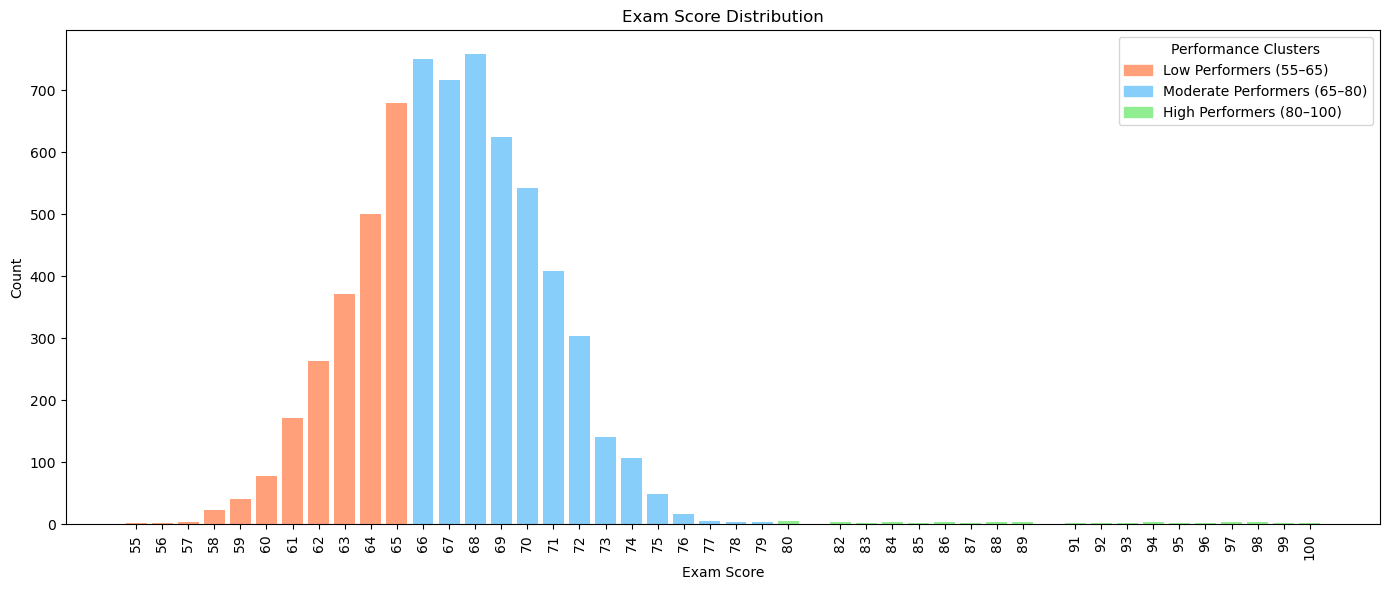

In [14]:
# Function to map score -> segment
def score_segment(score):
    if 55 <= score <=65:
        return 'Low Performers'
    elif 66 <= score <80:
        return 'Moderate Performers'
    else:
        return 'High Performers'

# Map every score to a segment for coloring the bars
segments_for_scores = [score_segment(s) for s in vc.index]

# FIXED color dictionary to match segment names
segment_colors = {
    "Low Performers": "#FFA07A",        # light salmon
    "Moderate Performers": "#87CEFA",   # sky blue
    "High Performers": "#90EE90",       # light green
}

# Build list of bar colors
bar_colors = [segment_colors.get(seg, "#D3D3D3") for seg in segments_for_scores]

# Plot
plt.figure(figsize=(14,6))


bars = plt.bar(vc.index, vc.values, color=bar_colors)

plt.xlabel("Exam Score")
plt.ylabel("Count")
plt.title("Exam Score Distribution")
plt.xticks(vc.index, rotation=90)

# Legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(color=segment_colors["Low Performers"], label="Low Performers (55–65)"),
    Patch(color=segment_colors["Moderate Performers"], label="Moderate Performers (65–80)"),
    Patch(color=segment_colors["High Performers"], label="High Performers (80–100)")
]
plt.legend(handles=legend_handles, title="Performance Clusters", loc="upper right")

plt.tight_layout()
plt.show()


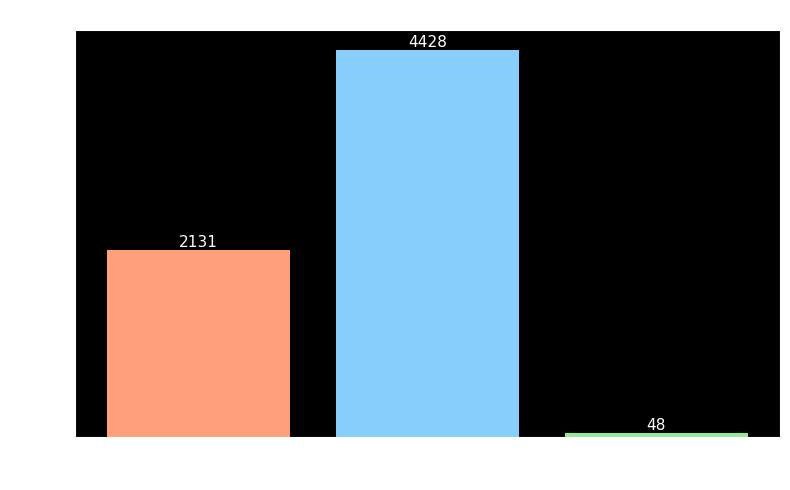

In [15]:
data['segment'] = data['exam_score'].apply(score_segment)

# Count per segment
segment_counts = data['segment'].value_counts().reindex(
    ['Low Performers','Moderate Performers','High Performers']
)

# Colors for the bars
colors = ["#FFA07A", "#87CEFA", "#90EE90"]

# Plot
plt.figure(figsize=(8,5))
plt.style.use('dark_background')
bars = plt.bar(segment_counts.index, segment_counts.values, color=colors)

plt.xlabel("Performance Groups")
plt.ylabel("Number of Students")
plt.title("Students Distribution Across Three Performance Segments")

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center', va='bottom', fontsize=11
    )

plt.tight_layout()
plt.show()

In [16]:

# numeric-only descriptive stats per segment
numeric_cols = data.select_dtypes(include='number').columns
desc_low = data[data["segment"] == "Low Performers"][numeric_cols].describe(include='all')
desc_mod = data[data["segment"] == "Moderate Performers"][numeric_cols].describe(include='all')
desc_high = data[data["segment"] == "High Performers"][numeric_cols].describe(include='all')

desc_low

,hours_studied,attendance,sleep_hours,previous_scores,tutoring_sessions,physical_activity,exam_score
count,2131.000000,2131.000000,2131.000000,2131.000000,2131.000000,2131.000000,2131.000000
mean,16.727827,70.770061,7.038010,71.911779,1.249648,2.935711,63.334585
std,5.309489,8.182121,1.457041,14.128176,1.122787,1.036469,1.687630
min,1.000000,60.000000,4.000000,50.000000,0.000000,0.000000,55.000000
25%,13.000000,64.000000,6.000000,60.000000,0.000000,2.000000,62.000000
50%,17.000000,69.000000,7.000000,70.000000,1.000000,3.000000,64.000000
75%,20.000000,76.000000,8.000000,83.000000,2.000000,4.000000,65.000000
max,34.000000,100.000000,10.000000,100.000000,7.000000,6.000000,65.000000


In [17]:
desc_mod

,hours_studied,attendance,sleep_hours,previous_scores,tutoring_sessions,physical_activity,exam_score
count,4428.000000,4428.000000,4428.000000,4428.000000,4428.000000,4428.000000,4428.000000
mean,21.543360,84.418699,7.026423,76.604336,1.610885,2.986224,68.869919
std,5.656149,10.239792,1.473193,14.260261,1.263245,1.027316,2.308051
min,2.000000,60.000000,4.000000,50.000000,0.000000,0.000000,66.000000
25%,18.000000,77.000000,6.000000,65.000000,1.000000,2.000000,67.000000
50%,21.000000,86.000000,7.000000,77.000000,1.000000,3.000000,68.000000
75%,25.000000,93.000000,8.000000,89.000000,2.000000,4.000000,70.000000
max,44.000000,100.000000,10.000000,100.000000,8.000000,6.000000,79.000000


In [18]:
desc_high

,hours_studied,attendance,sleep_hours,previous_scores,tutoring_sessions,physical_activity,exam_score
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,19.500000,79.041667,6.875000,73.812500,1.520833,2.666667,89.645833
std,6.562304,11.343680,1.510601,16.380653,1.184826,1.098032,6.369774
min,1.000000,61.000000,4.000000,52.000000,0.000000,0.000000,80.000000
25%,16.000000,70.000000,6.000000,56.750000,1.000000,2.000000,84.000000
50%,20.500000,76.000000,7.000000,75.500000,1.000000,3.000000,89.000000
75%,24.250000,90.000000,8.000000,90.250000,2.000000,3.000000,95.000000
max,31.000000,99.000000,10.000000,98.000000,5.000000,5.000000,100.000000


In [19]:
gen = data['gender'].value_counts()

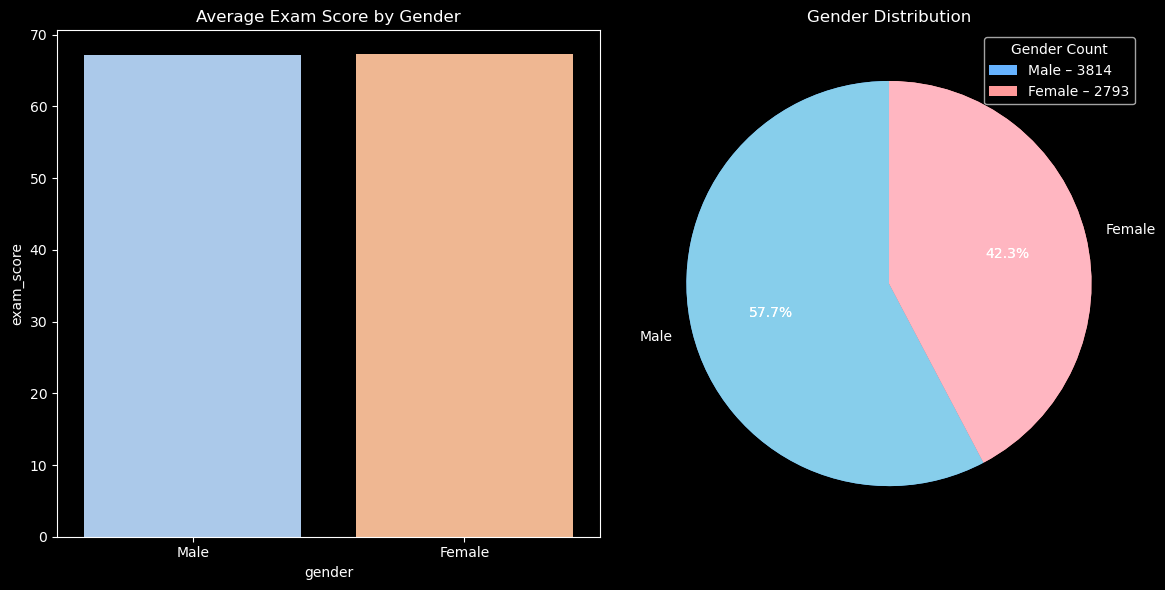

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Barplot
sns.barplot(data, x='gender', y='exam_score', ci=None, palette='pastel', ax=axes[0])
axes[0].set_title("Average Exam Score by Gender")

# Pie chart
gender_counts = data['gender'].value_counts()
# Creating Legend
legend_labels = [f"{label} – {count}" for label, count in zip(gender_counts.index, gender_counts.values)]

# Draw the pie
patches, _, _ = axes[1].pie(
    gender_counts,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff','#ff9999']
)

axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue','lightpink'])
axes[1].set_title("Gender Distribution")

axes[1].legend(
    patches,
    legend_labels,
    title="Gender Count",
    loc="upper right"
)

plt.tight_layout()
plt.show()

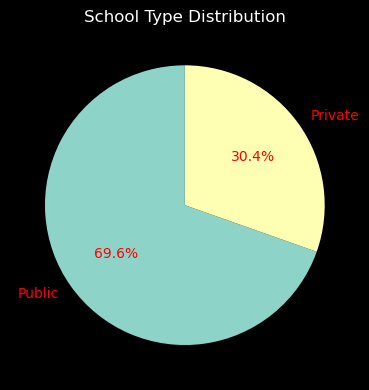

In [21]:

plt.figure(figsize=(4,4))

school_counts = data["school_type"].value_counts()

plt.pie(
    school_counts.values,
    labels=school_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"color": "red"}    # <<< CHANGE TEXT COLOR HERE
)

plt.title("School Type Distribution", color="white")   # title color
plt.tight_layout()
plt.show()


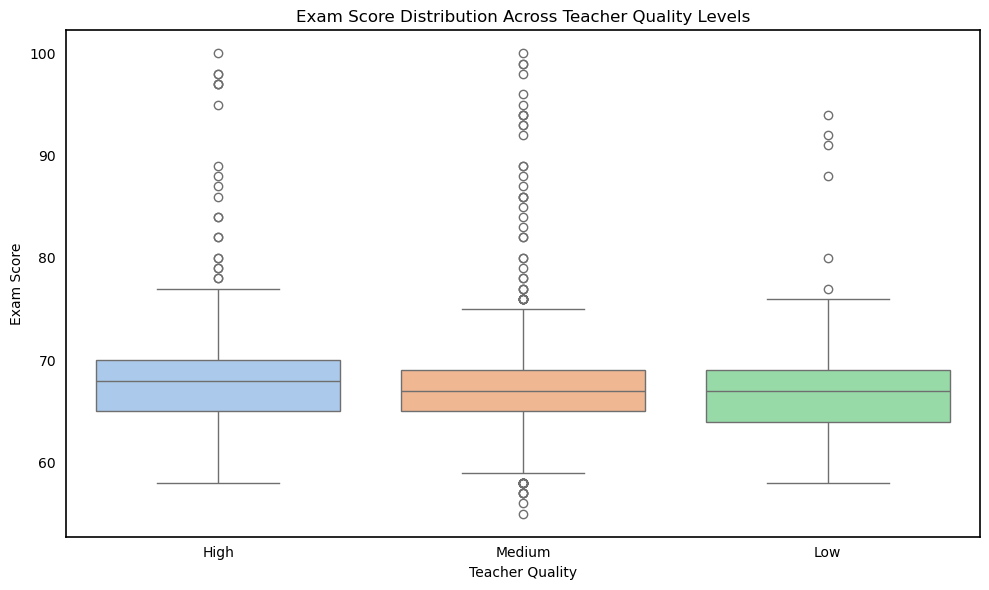

In [22]:

plt.figure(figsize=(10,6), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")
sns.boxplot(
    data=data,
    x="teacher_quality",
    y="exam_score",
    order=["High", "Medium", "Low"],
    palette="pastel"
)

plt.title("Exam Score Distribution Across Teacher Quality Levels", color='black')
plt.xlabel("Teacher Quality", color='black')
plt.ylabel("Exam Score", color='black')
plt.xticks(color="black")
plt.yticks(color="black")

for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()


In [23]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=data,
    x="motivation_level",
    y="exam_score",
    order=order,
    ci=None,
    palette="pastel"
)

plt.title("Average Exam Score by Motivation Level")
plt.xlabel("Motivation Level")
plt.ylabel("Average Exam Score")
plt.tight_layout()


plt.show()

NameError: name 'order' is not defined

<Figure size 1000x600 with 0 Axes>

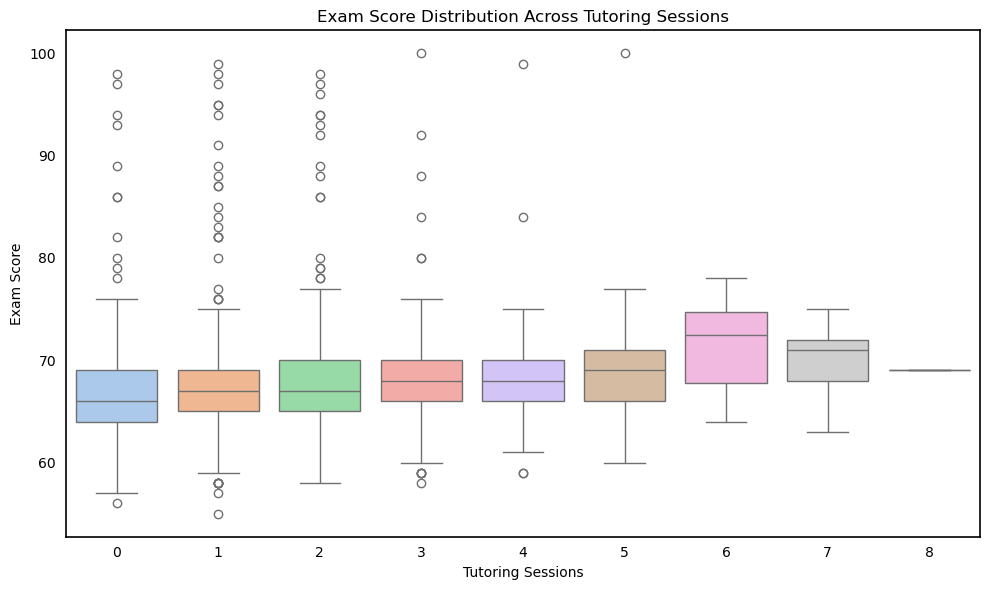

In [24]:



# Create corrected boxplot with white background
plt.style.use('dark_background')

fig = plt.figure(figsize=(10,6), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

sns.boxplot(
    data=data,
    x="tutoring_sessions",
    y="exam_score",
    palette="pastel"
)

plt.title("Exam Score Distribution Across Tutoring Sessions", color="black")
plt.xlabel("Tutoring Sessions", color="black")
plt.ylabel("Exam Score", color="black")

plt.xticks(color="black")
plt.yticks(color="black")

# Outline fix
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()


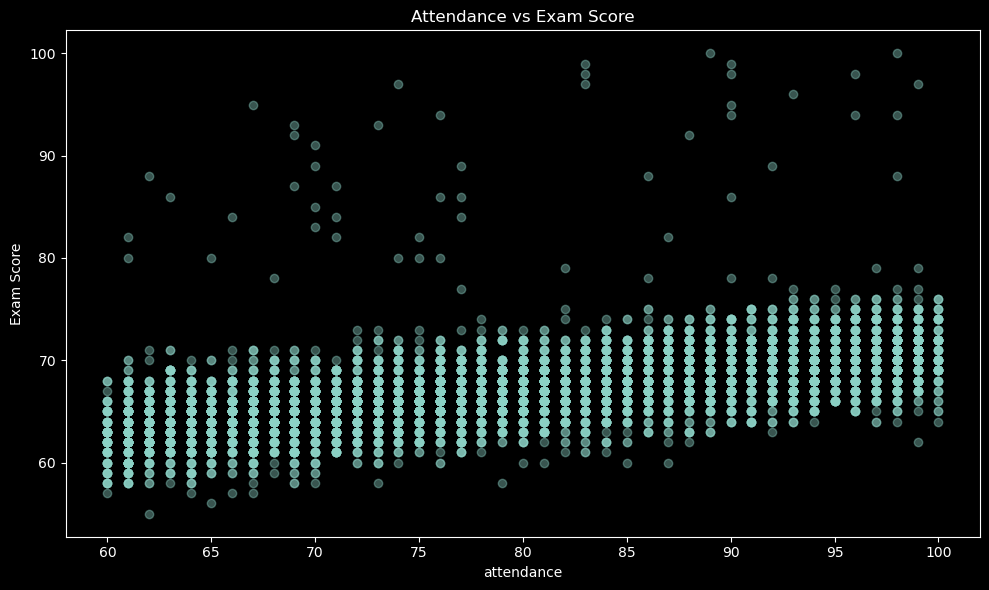

In [26]:


# Scatter plot: Previous Scores vs Exam Score
plt.figure(figsize=(10,6))

plt.scatter(
    data["attendance"],
    data["exam_score"],
    alpha=0.4,
)

plt.title("Attendance vs Exam Score")
plt.xlabel("attendance")
plt.ylabel("Exam Score")

plt.tight_layout()

plt.show()
